# Robustness Comparison

This notebook compares the baseline CNN and the augmented CNN under clean and corrupted CIFAR-10 test conditions.

Both models use the same architecture and training configuration, while the augmented model was trained with random cropping and horizontal flipping. The models are evaluated under identical Gaussian noise, Gaussian blur, and brightness-shift conditions to determine whether standard data augmentation improves robustness to image corruptions that were not explicitly included during training.

In [11]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import DataLoader


mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [2]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

models_dir = Path("../models")

baseline_checkpoint = models_dir / "baseline_cnn_best.pth"
augmented_checkpoint = models_dir / "augmented_cnn_best.pth"

baseline_model = BaselineCNN().to(device)
baseline_model.load_state_dict(
    torch.load(
        baseline_checkpoint,
        map_location=device,
        weights_only=True
    )
)
baseline_model.eval()

augmented_model = BaselineCNN().to(device)
augmented_model.load_state_dict(
    torch.load(
        augmented_checkpoint,
        map_location=device,
        weights_only=True
    )
)
augmented_model.eval()

print("Both model checkpoints loaded successfully.")

Both model checkpoints loaded successfully.


In [3]:
criterion = nn.CrossEntropyLoss()

def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    average_loss = running_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [4]:
clean_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

clean_test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=False,
    transform=clean_transform
)

clean_test_loader = DataLoader(
    clean_test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

In [6]:
baseline_clean_loss, baseline_clean_accuracy = evaluate_model(
    baseline_model,
    clean_test_loader,
    criterion,
    device
)

augmented_clean_loss, augmented_clean_accuracy = evaluate_model(
    augmented_model,
    clean_test_loader,
    criterion,
    device
)

print("Baseline CNN")
print(f"Clean Test Loss: {baseline_clean_loss:.4f}")
print(f"Clean Test Accuracy: {baseline_clean_accuracy:.4f}")

print("\nAugmented CNN")
print(f"Clean Test Loss: {augmented_clean_loss:.4f}")
print(f"Clean Test Accuracy: {augmented_clean_accuracy:.4f}")

print(
    f"\nAccuracy Difference: "
    f"{augmented_clean_accuracy - baseline_clean_accuracy:+.4f}"
)

Baseline CNN
Clean Test Loss: 0.8143
Clean Test Accuracy: 0.7152

Augmented CNN
Clean Test Loss: 0.8085
Clean Test Accuracy: 0.7187

Accuracy Difference: +0.0035


## Clean Performance

Before evaluating corrupted inputs, both model checkpoints were evaluated on the clean CIFAR-10 test set to verify that their previously reported performance was reproduced.

The baseline CNN achieved 71.52% accuracy, while the augmented CNN achieved 71.87%. The similar clean performance provides a common reference point for the subsequent robustness comparison.

## Gaussian Noise Robustness

The baseline and augmented CNNs are evaluated across the same Gaussian noise severity levels used in the baseline corruption experiment. The random seed is reset before evaluating each model so that both models receive the same noise realizations at each severity level.

In [8]:
class AddGaussianNoise:
    def __init__(self, std=0.1):
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std
        noisy_tensor = tensor + noise

        return torch.clamp(noisy_tensor, 0.0, 1.0)

noise_levels = [0.05, 0.10, 0.20]

noise_comparison_results = []

for noise_std in noise_levels:
    noise_transform = transforms.Compose([
        transforms.ToTensor(),
        AddGaussianNoise(std=noise_std),
        transforms.Normalize(mean=mean, std=std)
    ])

    noise_dataset = torchvision.datasets.CIFAR10(
        root="../data",
        train=False,
        download=False,
        transform=noise_transform
    )

    noise_loader = DataLoader(
        noise_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0
    )

    # Reset the seed so both models receive the same noisy images
    torch.manual_seed(42)

    baseline_loss, baseline_accuracy = evaluate_model(
        baseline_model,
        noise_loader,
        criterion,
        device
    )

    torch.manual_seed(42)

    augmented_loss, augmented_accuracy = evaluate_model(
        augmented_model,
        noise_loader,
        criterion,
        device
    )

    accuracy_difference = augmented_accuracy - baseline_accuracy

    noise_comparison_results.append({
        "std": noise_std,
        "baseline_loss": baseline_loss,
        "baseline_accuracy": baseline_accuracy,
        "augmented_loss": augmented_loss,
        "augmented_accuracy": augmented_accuracy,
        "accuracy_difference": accuracy_difference
    })

    print(
        f"Noise Std: {noise_std:.2f} | "
        f"Baseline Acc: {baseline_accuracy:.4f} | "
        f"Augmented Acc: {augmented_accuracy:.4f} | "
        f"Difference: {accuracy_difference:+.4f}"
    )

Noise Std: 0.05 | Baseline Acc: 0.6735 | Augmented Acc: 0.6124 | Difference: -0.0611
Noise Std: 0.10 | Baseline Acc: 0.5398 | Augmented Acc: 0.4337 | Difference: -0.1061
Noise Std: 0.20 | Baseline Acc: 0.2998 | Augmented Acc: 0.2674 | Difference: -0.0324


### Gaussian Noise Results

The augmented CNN did not improve robustness to Gaussian noise. Across all three noise levels, its accuracy was lower than that of the baseline CNN.

At noise standard deviations of `0.05`, `0.10`, and `0.20`, the augmented model underperformed the baseline by 6.11, 10.61, and 3.24 percentage points, respectively. The largest difference occurred at the moderate noise level of `0.10`, where baseline accuracy was 53.98% compared with 43.37% for the augmented model.

Although random cropping and horizontal flipping maintained comparable clean test performance, the robustness gained from these geometric transformations did not transfer to Gaussian noise in this experiment.

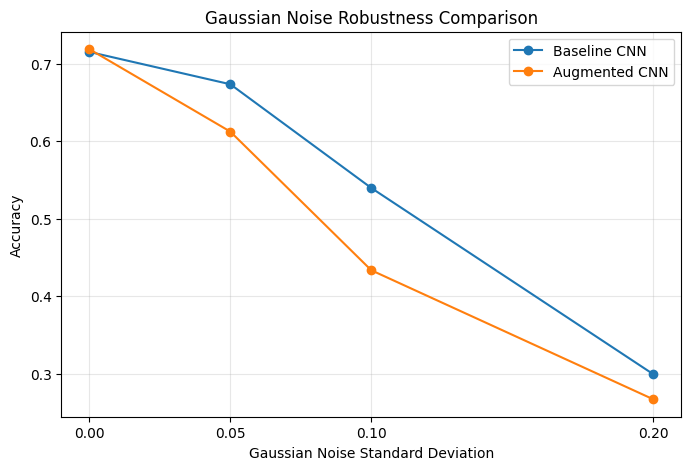

In [15]:
noise_stds = [0.0] + [
    result["std"] for result in noise_comparison_results
]

baseline_noise_accuracies = [baseline_clean_accuracy] + [
    result["baseline_accuracy"]
    for result in noise_comparison_results
]

augmented_noise_accuracies = [augmented_clean_accuracy] + [
    result["augmented_accuracy"]
    for result in noise_comparison_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    noise_stds,
    baseline_noise_accuracies,
    marker="o",
    label="Baseline CNN"
)

plt.plot(
    noise_stds,
    augmented_noise_accuracies,
    marker="o",
    label="Augmented CNN"
)

plt.xlabel("Gaussian Noise Standard Deviation")
plt.ylabel("Accuracy")
plt.title("Gaussian Noise Robustness Comparison")
plt.xticks(noise_stds)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The baseline and augmented CNNs achieved nearly identical accuracy on clean test images. However, the augmented CNN showed a steeper decline in accuracy as Gaussian noise increased.

The largest difference occurred at a noise standard deviation of `0.10`, where the augmented model underperformed the baseline by 10.61 percentage points. This suggests that the geometric augmentation used during training did not transfer to improved robustness against pixel-level Gaussian noise.

## Gaussian Blur Robustness

The baseline and augmented CNNs are evaluated across the same Gaussian blur severity levels used in the baseline corruption experiment. Both models receive identical blurred test images at each severity level.

In [19]:
blur_levels = [
    {
        "label": "Weak",
        "kernel_size": 3,
        "sigma": 0.5
    },
    {
        "label": "Moderate",
        "kernel_size": 3,
        "sigma": 1.0
    },
    {
        "label": "Strong",
        "kernel_size": 5,
        "sigma": 1.5
    }
]

blur_comparison_results = []

for blur_level in blur_levels:
    blur_transform = transforms.Compose([
        transforms.GaussianBlur(
            kernel_size=blur_level["kernel_size"],
            sigma=blur_level["sigma"]
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    blur_dataset = torchvision.datasets.CIFAR10(
        root="../data",
        train=False,
        download=False,
        transform=blur_transform
    )

    blur_loader = DataLoader(
        blur_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0
    )

    baseline_loss, baseline_accuracy = evaluate_model(
        baseline_model,
        blur_loader,
        criterion,
        device
    )

    augmented_loss, augmented_accuracy = evaluate_model(
        augmented_model,
        blur_loader,
        criterion,
        device
    )

    accuracy_difference = augmented_accuracy - baseline_accuracy

    blur_comparison_results.append({
        "label": blur_level["label"],
        "kernel_size": blur_level["kernel_size"],
        "sigma": blur_level["sigma"],
        "baseline_loss": baseline_loss,
        "baseline_accuracy": baseline_accuracy,
        "augmented_loss": augmented_loss,
        "augmented_accuracy": augmented_accuracy,
        "accuracy_difference": accuracy_difference
    })

    print(
        f"{blur_level['label']:8s} | "
        f"Kernel: {blur_level['kernel_size']} | "
        f"Sigma: {blur_level['sigma']:.1f} | "
        f"Baseline Acc: {baseline_accuracy:.4f} | "
        f"Augmented Acc: {augmented_accuracy:.4f} | "
        f"Difference: {accuracy_difference:+.4f}"
    )

Weak     | Kernel: 3 | Sigma: 0.5 | Baseline Acc: 0.6904 | Augmented Acc: 0.6765 | Difference: -0.0139
Moderate | Kernel: 3 | Sigma: 1.0 | Baseline Acc: 0.5716 | Augmented Acc: 0.5044 | Difference: -0.0672
Strong   | Kernel: 5 | Sigma: 1.5 | Baseline Acc: 0.4060 | Augmented Acc: 0.3538 | Difference: -0.0522


### Gaussian Blur Results

The augmented CNN did not improve robustness to Gaussian blur. Its accuracy was lower than the baseline CNN at all three blur severity levels.

At the weak, moderate, and strong blur settings, the augmented model underperformed the baseline by 1.39, 6.72, and 5.22 percentage points, respectively. The performance gap was small under weak blur but became more pronounced at moderate and strong blur levels.

Together with the Gaussian noise results, these findings indicate that the geometric augmentation used during training did not transfer to improved robustness against these image corruptions.

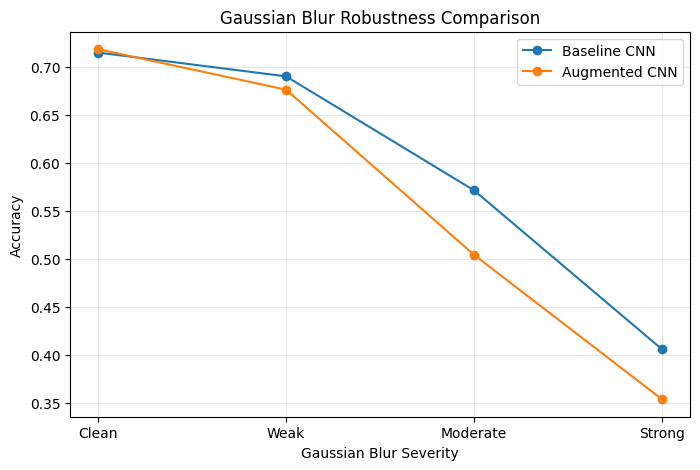

In [20]:
blur_labels = ["Clean"] + [
    result["label"] for result in blur_comparison_results
]

baseline_blur_accuracies = [baseline_clean_accuracy] + [
    result["baseline_accuracy"]
    for result in blur_comparison_results
]

augmented_blur_accuracies = [augmented_clean_accuracy] + [
    result["augmented_accuracy"]
    for result in blur_comparison_results
]


plt.figure(figsize=(8, 5))

plt.plot(
    blur_labels,
    baseline_blur_accuracies,
    marker="o",
    label="Baseline CNN"
)

plt.plot(
    blur_labels,
    augmented_blur_accuracies,
    marker="o",
    label="Augmented CNN"
)

plt.xlabel("Gaussian Blur Severity")
plt.ylabel("Accuracy")
plt.title("Gaussian Blur Robustness Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The two models show similar performance under clean and weak-blur conditions, but the augmented CNN degrades more rapidly as blur severity increases. The performance gap becomes most apparent at the moderate and strong blur levels.